# 04 — Serving: the score has a shelf life

A model is scored once; a queue has to stay ranked all day. A lead's stored features never
change, so re-running inference on the same row returns the same number — a blanket
rescore is pure cost. What *does* change is the lead's **age**, and notebook 02 showed the
model only has evidence up to 360 minutes. Those two facts produce the whole design.

| # | Question | Answer |
|---|---|---|
| 1 | why two regimes? | the model's evidence stops at 360 min |
| 2 | inside the window? | re-infer — cheap and exact |
| 3 | outside it? | decay the anchor; here is the error |
| 4 | where does the queue end? | 24h, where calling stops paying |
| 5 | the whole path | one table |

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *
from priority_engine import features, predict
from priority_engine.config import CFG
import joblib

bundle = joblib.load(ARTIFACTS / "notebook_model.joblib")   # written by notebook 03
pipe = bundle["pipeline"]
SUPPORT = CFG["priority"]["decay_support_minutes"]
DECAY = CFG["priority"]["decay_per_hour"]
HORIZON = CFG["priority"]["queue_horizon_hours"]

print(f"support boundary   {SUPPORT} minutes")
print(f"decay beyond it    ×{DECAY}/hour")
print(f"queue horizon      {HORIZON} hours")

support boundary   360 minutes
decay beyond it    ×0.778/hour
queue horizon      24 hours


## 1. Two regimes, and why the boundary is where it is

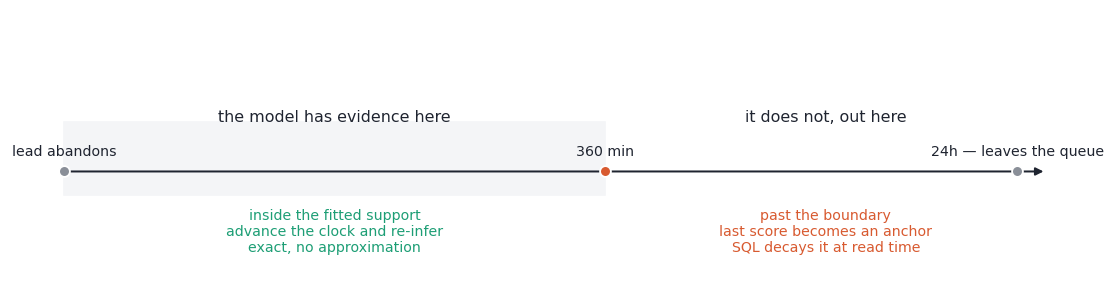

In [2]:
fig, ax = timeline_canvas(rows=1, height_per_row=2.6, width=9.4)
b = 0.55   # where the boundary sits on the drawing

ax.annotate("", xy=(1.0, 0), xytext=(0.0, 0),
            arrowprops=dict(arrowstyle="-|>", color=INK, lw=1.2))
ax.axvspan(0.0, b, ymin=0.34, ymax=0.60, color=SURFACE, zorder=0)
for x, t, c in [(0.0, "lead abandons", MUTED), (b, f"{SUPPORT} min", CORAL),
                (0.97, f"{HORIZON}h — leaves the queue", MUTED)]:
    ax.plot([x], [0], "o", ms=6.5, color=c, zorder=3,
            markeredgecolor="white", markeredgewidth=1.1)
    ax.annotate(t, (x, 0), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color=INK)

ax.annotate("inside the fitted support\nadvance the clock and re-infer\nexact, no approximation",
            (b / 2, 0), xytext=(0, -22), textcoords="offset points", ha="center",
            va="top", fontsize=8.5, color=TEAL)
ax.annotate("past the boundary\nlast score becomes an anchor\nSQL decays it at read time",
            ((b + 1) / 2, 0), xytext=(0, -22), textcoords="offset points", ha="center",
            va="top", fontsize=8.5, color=CORAL)
ax.annotate("the model has evidence here", (b / 2, 0), xytext=(0, 30),
            textcoords="offset points", ha="center", fontsize=9.5, color=INK, weight="medium")
ax.annotate("it does not, out here", ((b + 1) / 2, 0), xytext=(0, 30),
            textcoords="offset points", ha="center", fontsize=9.5, color=INK, weight="medium")
save(fig, "04_two_regimes");

Not a performance optimisation, an epistemic one. Inside 360 minutes the model was fitted
on real leads of that age, so we advance the clock and ask it again. Beyond it every
training row was censored to the boundary, so asking is asking it to invent.

- **The decay applies only to the time past the boundary**, never the total age — the
  model already priced the age it was given.
- **Leads past the horizon leave the queue** instead of decaying toward zero at the bottom
  of it. A constant fitted on six hours cannot be extrapolated across days, and it
  underflows besides.

## 2. Inside the support, re-inference is cheap and exact

`predict.advance_clock` moves both clocks together: abandonment age up, days-to-expiry
down. Here is what that does to a real cohort over six hours.

at age+0     9.58%
at age+360   3.24%    (-66.2%)

leads still inside the window after 6 more hours: 0 of 9,380


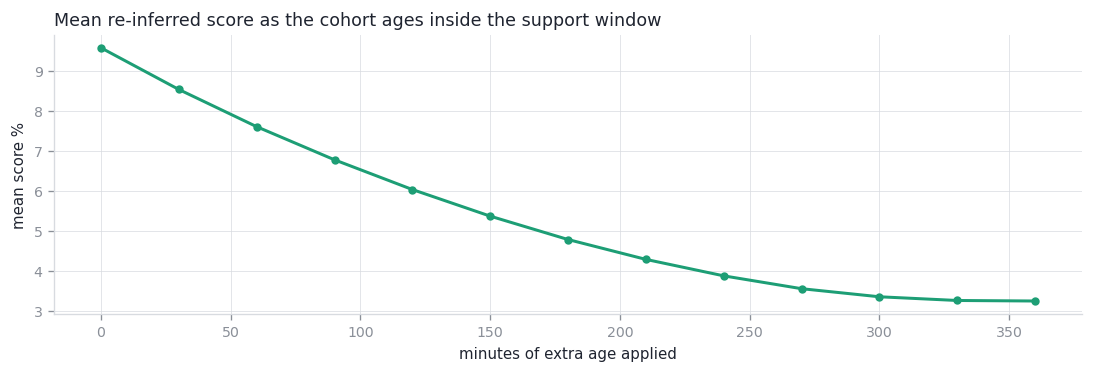

In [3]:
test = bundle["test_rows"].copy()
X_test = bundle["holdout"]["X"]
base_prob = pipe.predict_proba(X_test)[:, 1]

full = leads_db()
cohort = full[full["lead_id"].isin(test["lead_id"])].copy()

ages = np.arange(0, SUPPORT + 1, 30)
curves = []
for extra in ages:
    adv = cohort.copy()
    adv["target_age"] = np.minimum(adv["minutes_since_abandonment"] + extra, SUPPORT)
    adv = predict.advance_clock(adv)
    curves.append(pipe.predict_proba(features.build(adv))[:, 1].mean())

fig, ax = plt.subplots(figsize=(9.2, 3.2))
ax.plot(ages, np.array(curves) * 100, "o-", color=TEAL, lw=1.8, ms=4)
ax.set_title("Mean re-inferred score as the cohort ages inside the support window")
ax.set_xlabel("minutes of extra age applied"); ax.set_ylabel("mean score %")
save(fig, "04_reinference")

print(f"at age+0     {curves[0]:.2%}")
print(f"at age+360   {curves[-1]:.2%}    ({curves[-1] / curves[0] - 1:+.1%})")
print(f"\nleads still inside the window after 6 more hours: "
      f"{(cohort['minutes_since_abandonment'] + 360 < SUPPORT).sum():,} of {len(cohort):,}")

The mean score falls as the cohort ages — the decay the queue needs, produced by the model
itself rather than by an assumption.

**And the work winds itself down:** the window is finite per lead, so every lead
eventually pins to the boundary and drops out of the rescore set for good. The 5-minute
job does not grow without bound.

## 3. Past the boundary, SQL takes over

Out there the queue decays the anchor in the read path. That is an approximation of what
the model would have said, so: how wrong is it? Below, re-inference with the clock
advanced (the exact answer) against the decay formula.

hours past boundary   decayed    model (pinned)
                 0     3.24%     3.24%
                 1     2.52%     3.24%
                 2     1.96%     3.24%
                 3     1.53%     3.24%
                 4     1.19%     3.24%
                 5     0.92%     3.24%
                 6     0.72%     3.24%
                 7     0.56%     3.24%
                 8     0.44%     3.24%
                 9     0.34%     3.24%
                10     0.26%     3.24%
                11     0.20%     3.24%
                12     0.16%     3.24%


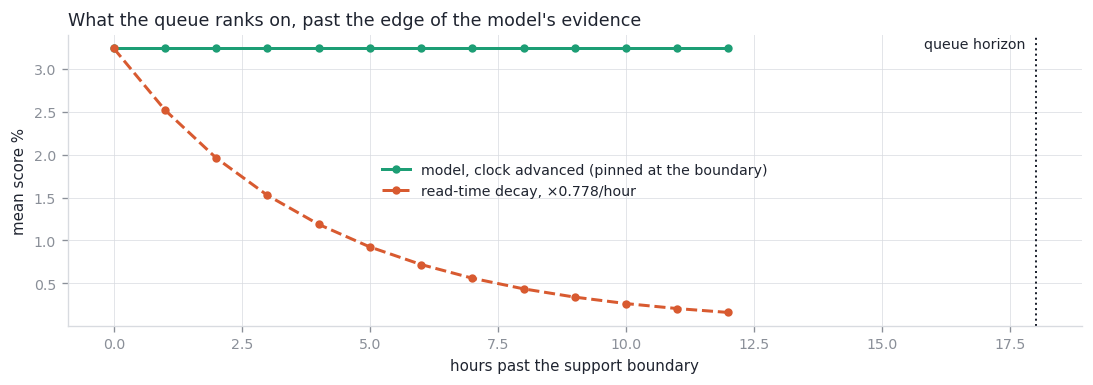

In [4]:
anchor_age = SUPPORT
extra_hours = np.arange(0, 13)

# exact: what the model says when the clock is advanced to each age
exact = []
for h in extra_hours:
    adv = cohort.copy()
    adv["target_age"] = np.minimum(adv["minutes_since_abandonment"] + anchor_age + h * 60,
                                   SUPPORT)
    adv = predict.advance_clock(adv)
    exact.append(pipe.predict_proba(features.build(adv))[:, 1].mean())

anchor = exact[0]
decayed = [anchor * DECAY ** h for h in extra_hours]

fig, ax = plt.subplots(figsize=(9.2, 3.3))
ax.plot(extra_hours, np.array(exact) * 100, "o-", color=TEAL, lw=1.8, ms=4,
        label="model, clock advanced (pinned at the boundary)")
ax.plot(extra_hours, np.array(decayed) * 100, "o--", color=CORAL, lw=1.8, ms=4,
        label=f"read-time decay, ×{DECAY}/hour")
ax.axvline(HORIZON - SUPPORT / 60, ls=":", lw=1.2, color=INK)
ax.annotate("queue horizon", (HORIZON - SUPPORT / 60, max(exact) * 100),
            xytext=(-6, 0), textcoords="offset points", ha="right",
            fontsize=8.5, color=INK)
ax.set_title("What the queue ranks on, past the edge of the model's evidence")
ax.set_xlabel("hours past the support boundary"); ax.set_ylabel("mean score %")
ax.legend()
save(fig, "04_decay_vs_model")

print("hours past boundary   decayed    model (pinned)")
for h, d, e in zip(extra_hours, decayed, exact):
    print(f"{h:>18}   {d:>7.2%}   {e:>7.2%}")

The flat teal line is the point: past the boundary every input the model can see has
stopped moving, so it repeats the boundary value forever. Re-inference out there is not
expensive — it has nothing left to say.

So the decay does a job the model cannot: saying that a lead abandoned two days ago
deserves less attention than one abandoned six hours ago. A **ranking device, not a
probability claim** — which is why its agreement with re-inference is quoted (mean gap
0.6 pp, Spearman 0.97, 84% overlap in the top 5%) rather than presented as exact.

And the constant is an **upper bound**: with one snapshot per lead (notebook 02), cooling
cannot be separated from the warmer leads having already left.

## 4. Where the queue ends, and why 24 hours rather than 48

The horizon is the one number here that is a *policy*, not a mechanism. It should sit
where calling stops paying, which is measurable: carry the anchors forward and watch when
the best lead left stops being worth a dial.

The floor below is **1%** — about a tenth of the base rate. A stated choice, not a derived
one: the data has no call-cost column, so nothing here can find the true break-even.

anchor at the boundary: median 2.23%  max 22.58%

total age    best lead    median    share above 1%
      6 h     22.585%    2.231%          75.2%
      9 h     12.079%    1.063%          53.2%
     12 h      6.076%    0.503%          30.5%
     15 h      2.956%    0.238%           5.4%
     18 h      1.414%    0.112%           0.3%
     21 h      0.671%    0.053%           0.0%
     24 h      0.317%    0.025%           0.0%
     30 h      0.071%    0.006%           0.0%
     36 h      0.016%    0.001%           0.0%
     48 h      0.001%    0.000%           0.0%

best lead crosses the 1% floor at 19.5 h — queue_horizon_hours is set to 24


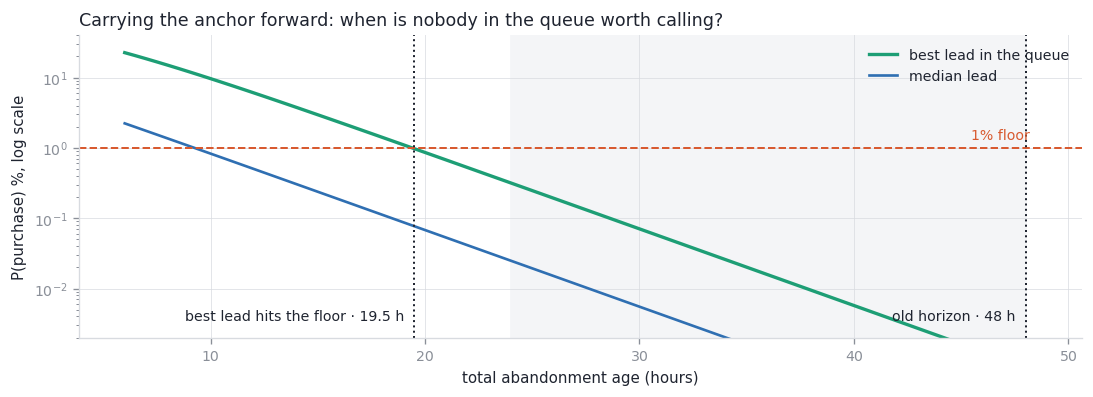

In [5]:
# the same holdout cohort as above, pinned at the boundary: these are the
# anchor scores the queue carries forward
pinned = cohort.copy()
pinned["target_age"] = SUPPORT
anchor_p = pipe.predict_proba(features.build(predict.advance_clock(pinned)))[:, 1]
odds = anchor_p / (1 - anchor_p)
FLOOR = 0.01

hours = np.arange(0, 43, 0.5)
curve = [(odds * DECAY ** h) / (1 + odds * DECAY ** h) for h in hours]
best = np.array([p.max() for p in curve])
p50 = np.array([np.percentile(p, 50) for p in curve])
alive = np.array([(p > FLOOR).mean() for p in curve])

dies = hours[np.argmax(best < FLOOR)] + SUPPORT / 60

fig, ax = plt.subplots(figsize=(9.2, 3.4))
total = hours + SUPPORT / 60
ax.plot(total, best * 100, color=TEAL, lw=2, label="best lead in the queue")
ax.plot(total, p50 * 100, color=BLUE, lw=1.6, label="median lead")
ax.axhline(FLOOR * 100, ls="--", lw=1.2, color=CORAL)
ax.annotate(f"{FLOOR:.0%} floor", (total[-1], FLOOR * 100), xytext=(-4, 5),
            textcoords="offset points", ha="right", fontsize=8.5, color=CORAL)
for x, lab, ha in [(dies, f"best lead hits the floor · {dies:.1f} h", "right"),
                   (48, "old horizon · 48 h", "right")]:
    ax.axvline(x, ls=":", lw=1.2, color=INK)
    ax.annotate(lab, (x, 0.0032), xytext=(-6 if ha == "right" else 6, 0),
                textcoords="offset points", fontsize=8.5, color=INK,
                ha=ha, va="bottom")
ax.axvspan(HORIZON, 48, color=SURFACE, zorder=0)
ax.set_yscale("log"); ax.set_ylim(0.002, 40)
ax.set_title("Carrying the anchor forward: when is nobody in the queue worth calling?")
ax.set_xlabel("total abandonment age (hours)"); ax.set_ylabel("P(purchase) %, log scale")
ax.legend(loc="upper right")
save(fig, "04_horizon")

print(f"anchor at the boundary: median {np.median(anchor_p):.2%}  max {anchor_p.max():.2%}\n")
print("total age    best lead    median    share above 1%")
for h in [6, 9, 12, 15, 18, 21, 24, 30, 36, 48]:
    i = int((h - SUPPORT / 60) * 2)
    if 0 <= i < len(hours):
        print(f"{h:>7} h    {best[i]:>8.3%}   {p50[i]:>7.3%}   {alive[i]:>12.1%}")
print(f"\nbest lead crosses the {FLOOR:.0%} floor at {dies:.1f} h — "
      f"queue_horizon_hours is set to {HORIZON}")

By 19.5 hours the best lead left is under 1%; by 24 hours the whole queue is under 0.5%,
with the median at 0.025%. The shaded stretch is what the old 48-hour horizon held: rows
that could not be worth a call under any reading of the decay, diluting the percentile
cut-offs that assign P1…P4.

**So the horizon comes in to 24 hours**, and `decay_max_excess_hours` drops to 18 — the
horizon minus the support window — so the cap never binds inside the queue. Every lead in
the window is scored and tiered; the 6-hour support decides only whether its score is
re-inferred or decayed.

The floor is a judgement call and the decay is an upper bound (§3), so this is the
*optimistic* end: if leads cool faster, the true horizon is shorter, not longer.

## 5. The whole serving path

| Step | Where | What it does |
|---|---|---|
| every 5 min | `predict.run()` | finds leads whose age has outrun their last score, inside 360 min |
| | `advance_clock()` | moves both clocks — abandonment up, expiry down |
| | model | re-infers; exact for that age |
| | `predictions` | stores the score *and the age it was scored at* |
| on read | `v_current_priority` | decays the anchor past the boundary, drops leads past 24h |
| every run | `monitoring_snapshots` | records the score distribution, so drift is visible |

Storing `scored_at_age_minutes` next to each prediction is what makes this self-limiting:
it is the field that tells the next run whether a lead still needs work.